In [ ]:
# prompt: mount google drive navigate to dir GEE_Exports

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os
os.chdir('/content/drive/My Drive/6400_final')


Mounted at /content/drive


In [ ]:
!pip install rasterio

In [ ]:
import geemap
import geopandas as gpd
import folium
from shapely.geometry import shape
import rasterio

In [ ]:
cd raw

/content/drive/.shortcut-targets-by-id/1vaXFv_HNGnjPBY9wfQi_6nBXh0jhAAUD/6400_final/raw



--- File: dakar_building_presence_height_2023.tif ---
Number of bands: 2
Band 1 Description: building_presence
Band 2 Description: building_height


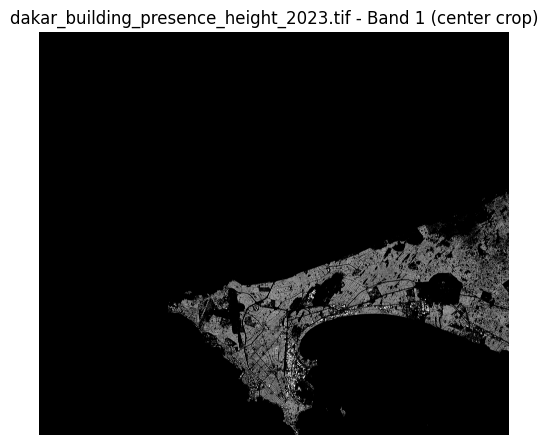


--- File: dakar_building_presence_height_2022.tif ---
Number of bands: 2
Band 1 Description: building_presence
Band 2 Description: building_height


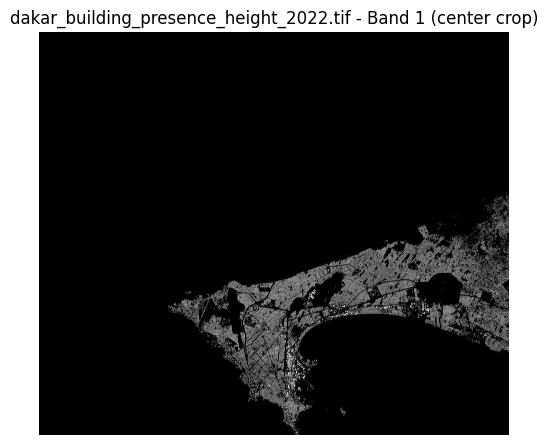


--- File: dakar_building_presence_height_2017.tif ---
Number of bands: 2
Band 1 Description: building_presence
Band 2 Description: building_height


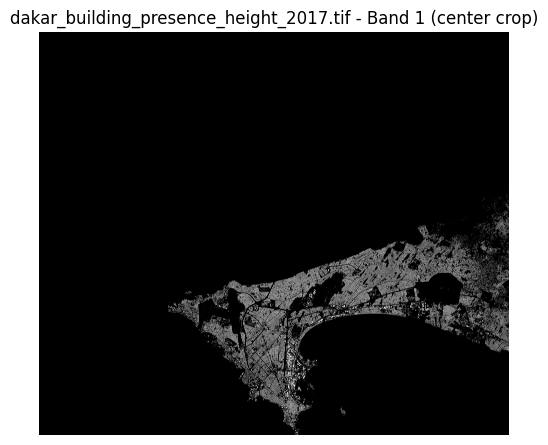


--- File: dakar_building_presence_height_2016.tif ---
Number of bands: 2
Band 1 Description: building_presence
Band 2 Description: building_height


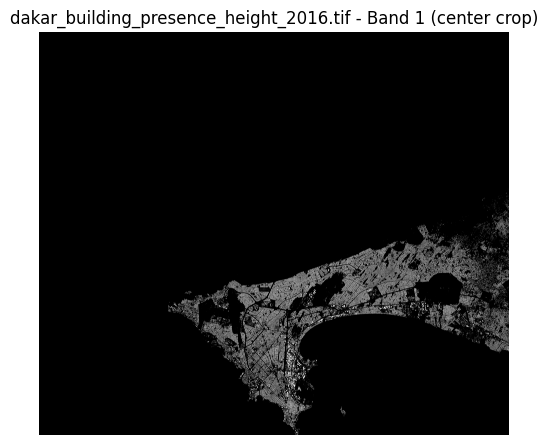

In [ ]:
import rasterio
import matplotlib.pyplot as plt
from rasterio.windows import Window
from glob import glob
import os

tif_files = glob(os.path.join('./*.tif'))

for tif_path in tif_files:
    print(f"\n--- File: {os.path.basename(tif_path)} ---")

    with rasterio.open(tif_path) as src:
        print(f"Number of bands: {src.count}")
        for i in range(1, src.count + 1):
            desc = src.descriptions[i - 1] or f"Band {i}"
            print(f"Band {i} Description: {desc}")

        # Optional: read a small center window to reduce RAM
        w, h = src.width // 4, src.height // 4
        window = Window(w, h, src.width // 2, src.height // 2)
        band1 = src.read(1, window=window)

        plt.figure(figsize=(5, 5))
        plt.title(f"{os.path.basename(tif_path)} - Band 1 (center crop)")
        plt.imshow(band1, cmap='gray')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        plt.close()  # Important to free memory

In [ ]:
pip install geopandas rasterio rasterstats networkx

In [ ]:
import rasterio
from rasterio.features import shapes
import geopandas as gpd
from shapely.geometry import shape

# Parameters
presence_tif = "/content/drive/.shortcut-targets-by-id/1vaXFv_HNGnjPBY9wfQi_6nBXh0jhAAUD/6400_final/raw/dakar_building_presence_height_2017.tif"

threshold = 0.35

# Open raster
with rasterio.open(presence_tif) as src:
    # Read the full presence mask efficiently as uint8 (0/1)
    # NOTE: For very large rasters, we can do this in chunks (see below)
    presence = src.read(1)
    mask = presence > threshold

    binary_presence = mask.astype("uint8")  # Convert boolean mask to 0/1 image

    results = (
      {'properties': {'value': v}, 'geometry': s}
      for s, v in shapes(binary_presence, mask=mask, transform=src.transform)
      if v == 1
  )

    # Convert to GeoDataFrame
    geoms = list(results)
    gdf = gpd.GeoDataFrame.from_features(geoms)
    gdf = gdf.set_crs(src.crs)

# Optional: project to UTM for accurate area
gdf = gdf.to_crs(epsg=32633)  # or appropriate UTM for your region

# Filter small objects (noise)
gdf["area"] = gdf.geometry.area
gdf = gdf[gdf["area"] > 10]  # remove tiny polygons

# Save to GeoJSON
gdf.to_file("/content/drive/.shortcut-targets-by-id/1vaXFv_HNGnjPBY9wfQi_6nBXh0jhAAUD/6400_final/generated/buildings_2017.geojson", driver="GeoJSON")

In [ ]:
pip install rasterstats

In [ ]:
import rasterio

# Check CRS of raster
with rasterio.open(presence_tif) as src:
    print("Raster CRS:", src.crs)

gdf["area"] = gdf.geometry.area
gdf = gdf.to_crs("EPSG:4326")



Raster CRS: EPSG:4326


In [ ]:
from rasterstats import zonal_stats
#this step should take time if done correctly
# Open raster to confirm band order
with rasterio.open(presence_tif) as src:
    print(src.count)
    print(src.descriptions)  # optionally, confirm which band = height

# Compute zonal stats for band 1 (presence) and band 2 (height)
presence_stats = zonal_stats(gdf, presence_tif, stats=["mean"], band=1, geojson_out=False)
height_stats = zonal_stats(gdf, presence_tif, stats=["mean"], band=2, geojson_out=False)

# Add to GeoDataFrame
gdf["mean_presence"] = [s["mean"] if s["mean"] is not None else 0 for s in presence_stats]
gdf["mean_height"] = [s["mean"] if s["mean"] is not None else 0 for s in height_stats]

2
('building_presence', 'building_height')


/usr/local/lib/python3.11/dist-packages/rasterstats/io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


In [ ]:
import networkx as nx
from shapely.geometry import Polygon

# Ensure GeoDataFrame is in projected CRS (for square meters)
gdf = gdf.to_crs(epsg=32633)  # UTM Zone 33N (Dakar region)

# Recalculate area in square meters
gdf["area"] = gdf.geometry.area

# Initialize empty graph
G = nx.Graph()

# Add nodes with attributes
for idx, row in gdf.iterrows():
    G.add_node(idx,
               geometry=row.geometry,
               mean_presence=row["mean_presence"],
               mean_height=row["mean_height"],
               area=row["area"])  # now in square meters

# Build spatial index for efficiency
sindex = gdf.sindex

# Add edges based on shared boundaries
for idx, geom in gdf.geometry.items():
    possible_neighbors_index = list(sindex.intersection(geom.bounds))
    for neighbor_idx in possible_neighbors_index:
        if idx >= neighbor_idx:
            continue  # Avoid duplicate edges or self-edges
        neighbor_geom = gdf.geometry.iloc[neighbor_idx]
        if geom.touches(neighbor_geom):
            shared = geom.intersection(neighbor_geom)
            if shared.is_empty:
                continue
            shared_length = shared.length
            G.add_edge(idx, neighbor_idx, shared_length=shared_length)

In [ ]:
print(gdf["area"].describe())

count    9.103300e+04
mean     1.409265e+03
std      9.439490e+03
min      2.089848e+01
25%      1.050978e+02
50%      3.349400e+02
75%      9.673863e+02
max      1.603442e+06
Name: area, dtype: float64


In [ ]:
import pickle

with open("/content/drive/.shortcut-targets-by-id/1vaXFv_HNGnjPBY9wfQi_6nBXh0jhAAUD/6400_final/generated/building_network_2017.pkl", "wb") as f:
    pickle.dump(G, f)

In [ ]:
import geopandas as gpd
from shapely.geometry import LineString

# Create GeoDataFrame of nodes
node_gdf = gpd.GeoDataFrame.from_dict(
    {n: G.nodes[n] for n in G.nodes},
    orient="index",
    geometry="geometry",
    crs=gdf.crs
)

# Create GeoDataFrame of edges
edge_geoms = []
for u, v, data in G.edges(data=True):
    geom_u = G.nodes[u]["geometry"]
    geom_v = G.nodes[v]["geometry"]
    shared = geom_u.intersection(geom_v)
    if not shared.is_empty:
        edge_geoms.append({
            "source": u,
            "target": v,
            "shared_length": data["shared_length"],
            "geometry": shared
        })

edge_gdf = gpd.GeoDataFrame(edge_geoms, crs=gdf.crs)

In [ ]:
node_gdf.to_file("/content/drive/.shortcut-targets-by-id/1vaXFv_HNGnjPBY9wfQi_6nBXh0jhAAUD/6400_final/generated/network_nodes_2017.geojson", driver="GeoJSON")
edge_gdf.to_file("/content/drive/.shortcut-targets-by-id/1vaXFv_HNGnjPBY9wfQi_6nBXh0jhAAUD/6400_final/generated/network_edges_2017.geojson", driver="GeoJSON")

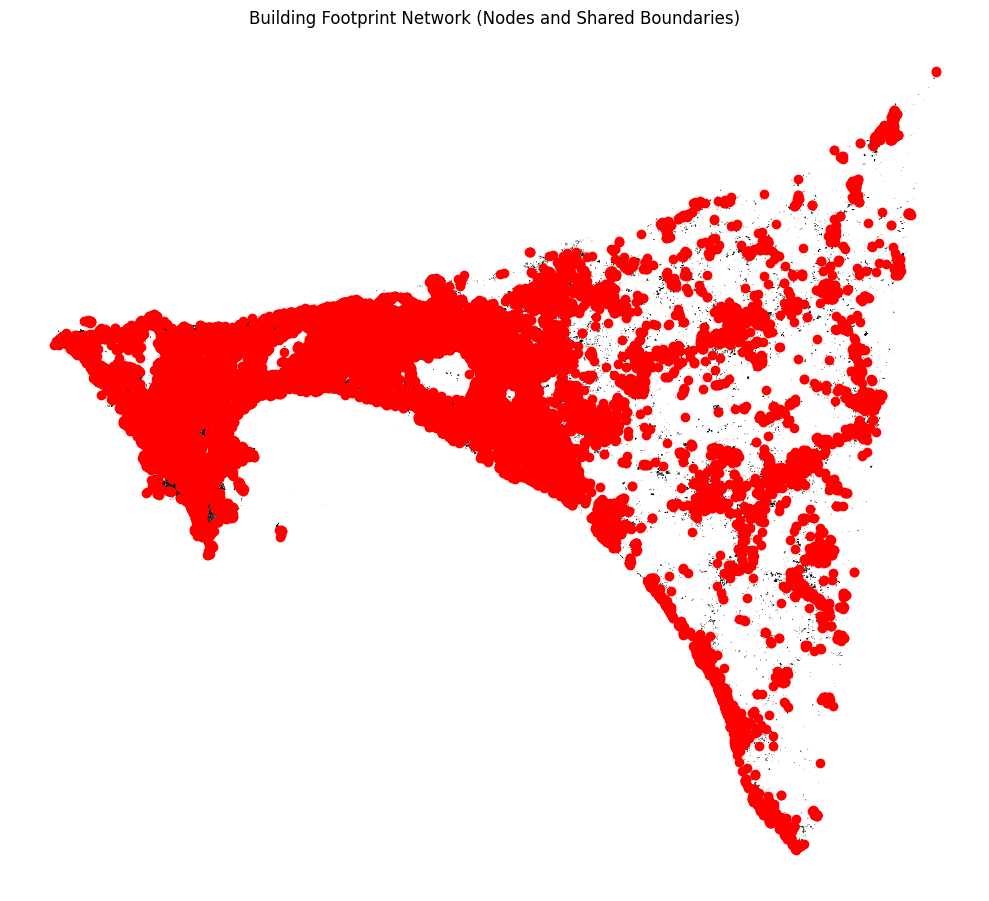

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
node_gdf.plot(ax=ax, facecolor='lightgray', edgecolor='black', linewidth=0.3)
edge_gdf.plot(ax=ax, color='red', linewidth=1)

plt.title("Building Footprint Network (Nodes and Shared Boundaries)")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import networkx as nx

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

import pandas as pd

# Extract node attributes
node_attrs = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index')

# Summary statistics
print("\n--- Node Attribute Summary ---")
print(node_attrs.describe())

Number of nodes: 91033
Number of edges: 16176

--- Node Attribute Summary ---
       mean_presence   mean_height          area
count   91033.000000  91033.000000  9.103300e+04
mean        0.472452      3.812168  1.409265e+03
std         0.154953      2.174113  9.439490e+03
min         0.200000      0.000000  2.089848e+01
25%         0.331875      2.197088  1.050978e+02
50%         0.504868      3.541016  3.349400e+02
75%         0.600218      5.004207  9.673863e+02
max         0.928854     44.194955  1.603442e+06


In [ ]:
edge_attrs = pd.DataFrame(
    [(u, v, d['shared_length']) for u, v, d in G.edges(data=True)],
    columns=["source", "target", "shared_length"]
)

print("\n--- Edge Attribute Summary ---")
print(edge_attrs["shared_length"].describe())
isolated = list(nx.isolates(G))
print("Number of isolated nodes:", len(isolated))
components = list(nx.connected_components(G))
print("Number of connected components:", len(components))

degrees = [deg for _, deg in G.degree()]
print("\n--- Node Degree Summary ---")
print(pd.Series(degrees).describe())


--- Edge Attribute Summary ---
count    16176.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: shared_length, dtype: float64
Number of isolated nodes: 67460
Number of connected components: 75694

--- Node Degree Summary ---
count    91033.000000
mean         0.355388
std          0.754039
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         38.000000
dtype: float64


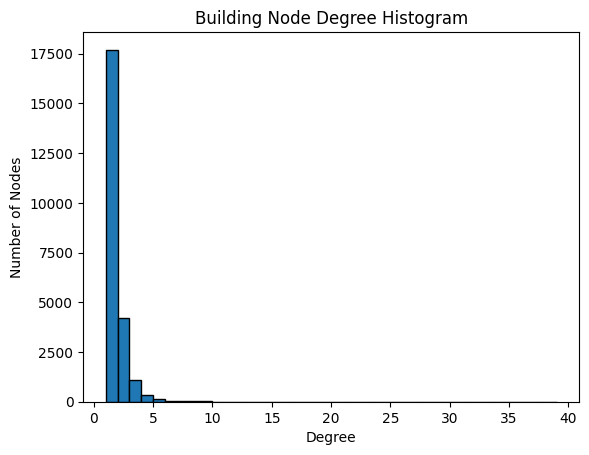

In [ ]:
import matplotlib.pyplot as plt

plt.hist(degrees, bins=range(1, max(degrees)+2), edgecolor='black')
plt.title("Building Node Degree Histogram")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")
plt.show()